I have modified the original tutorial colab sheet here to be more descriptive and to work on desktop.

General notes:
'kelsic' is the name of a person. The actual protein being evolved is translation initiation factor IF-1 from E coli.
The notebook cannot be run in one continuous flow - there is one environment for running most commands (evolvepro) and a separate envrionment for handling the protein language models (plm).

In [5]:
import os

## Setup:

In [15]:
colab_dir = "/Users/mitchsyberg-olsen/github/EvolvePro/colab/"
colab_output = colab_dir + "output/"

try:
    os.makedirs(colab_output)
except FileExistsError:
    pass

## Process

In [8]:
from evolvepro.src.process import generate_wt, generate_single_aa_mutants

wt_fasta = colab_output + "kelsic_WT.fasta"
mutants_fasta = colab_output + "kelsic_mutants.fasta"

# makes a fasta file with the given sequence.
generate_wt(wt_sequence='MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIRILTGDKVTVELTPYDLSKGRIVFRSR',
            output_file=wt_fasta)

# makes a multifasta file with every possible single AA substitution.
generate_single_aa_mutants(wt_fasta=wt_fasta,
                           output_file=mutants_fasta)


Number of mutants: 1369


In [10]:
from evolvepro.src.process import suggest_initial_mutants
suggest_initial_mutants(fasta_file=mutants_fasta,
                        num_mutants=12,
                        random_seed=42)


Suggested 12 mutants for testing:
1. R23K
2. T58E
3. I36D
4. V31C
5. I7A
6. K3F
7. Q10P
8. G38E
9. E4M
10. D61W
11. E4Y
12. R23N


## PLM

In [11]:
# execute this command in the terminal, using the plm conda environment.
# this command will:
# - download the indicated ESM model to /Users/mitchsyberg-olsen/.cache/torch/hub/checkpoints/esm1b_t33_650M_OR50S.pt
# - split the input fasta into batches according to toks_per_batch
# - extract embeddings into the concatenate_dir folder
# - produce a summary table named after the input fasta and model ie, "kelsic_mutants_esm1b_t33_650M_UR50S.csv"

script = "evolvepro/plm/esm/extract.py"
model = "esm1b_t33_650M_UR50S"
output_dir = colab_output + model

print(f"python {script} {model} {mutants_fasta} {output_dir} --toks_per_batch 512 --include mean --concatenate_dir {colab_output}")


python evolvepro/plm/esm/extract.py esm1b_t33_650M_UR50S /Users/mitchsyberg-olsen/github/EvolvePro/colab/output/kelsic_mutants.fasta /Users/mitchsyberg-olsen/github/EvolvePro/colab/output/esm1b_t33_650M_UR50S --toks_per_batch 512 --include mean --concatenate_dir /Users/mitchsyberg-olsen/github/EvolvePro/colab/output/


## Run EVOLVEpro

#### Round 1

evolve_experimental() produces 4 output files:

1 - this_round_variants.csv : useless file. This is just the names of the variants from the input excel file

2 - iteration.csv : useless file. This is the same file, but with an 'iteration' column. What does the iteration column do?

3 - df_test.csv : useless file. this is the predicted activities (listed as 'y_pred') of all variants except the ones from this round

4 - df_sorted_all : each single AA mutant in a sorted list based on 'y_pred', including columns for actual activity data. Refer to this file for actual results

In [18]:
from evolvepro.src.evolve import evolve_experimental

round_name = 'Round1'
round_files = ['kelsic_Round1.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name='kelsic',
    round_name=round_name,
    embeddings_base_path=colab_output,
    embeddings_file_name='kelsic_mutants_esm1b_t33_650M_UR50S.csv',
    round_base_path=colab_dir + 'rounds_data',
    round_file_names=round_files,
    wt_fasta_path=wt_fasta,
    rename_WT=False,
    number_of_variants=12,
    output_dir=colab_output
)

Processing kelsic - Round1
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
iteration shape: (12, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1357,)

Tested variants in this round: 12
59      D61W
169     R23N
268      E4Y
321      I7A
324     R23K
340      K3F
467     I36D
564     G38E
655     Q10P
965     V31C
996      E4M
1356    T58E
Name: variant, dtype: object

Top 12 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
739      E4L  0.960490       NaN              NaN              NaN   
1106     E4F  0.958967       NaN              NaN              NaN   
822      E4H  0.956250       NaN              NaN              NaN   
460      E4V  0.956198       NaN              NaN              NaN   
1036     E8Y  0.955170       NaN              NaN              NaN   
892      E4Q  0.951333       NaN              NaN              NaN   
483      E4N  0.950048       NaN          

/Users/mitchsyberg-olsen/github/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 2

In [20]:
round_name = 'Round2'
round_files = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name='kelsic',
    round_name=round_name,
    embeddings_base_path=colab_output,
    embeddings_file_name='kelsic_mutants_esm1b_t33_650M_UR50S.csv',
    round_base_path=colab_dir + 'rounds_data',
    round_file_names=round_files,
    wt_fasta_path=wt_fasta,
    rename_WT=False,
    number_of_variants=12,
    output_dir=colab_output
)

Processing kelsic - Round2
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
iteration shape: (24, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1345,)

Tested variants in this round: 24
59      D61W
162      E8C
169     R23N
211     T12M
268      E4Y
321      I7A
324     R23K
340      K3F
353     S71C
456      E8Q
460      E4V
467     I36D
483      E4N
564     G38E
608     T12C
655     Q10P
739      E4L
746      D5M
822      E4H
892      E4Q
965     V31C
996      E4M
1106     E4F
1356    T58E
Name: variant, dtype: object

Top 12 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
1365     D5F  0.998277       NaN              NaN              NaN   
909      E4I  0.994775       NaN              NaN              NaN   
820      D5I  0.990270       NaN              NaN              NaN   
1001     D5L  0.986245       NaN       

/Users/mitchsyberg-olsen/github/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 3

In [21]:
round_name = 'Round3'
round_files = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name='kelsic',
    round_name=round_name,
    embeddings_base_path=colab_output,
    embeddings_file_name='kelsic_mutants_esm1b_t33_650M_UR50S.csv',
    round_base_path=colab_dir + 'rounds_data',
    round_file_names=round_files,
    wt_fasta_path=wt_fasta,
    rename_WT=False,
    number_of_variants=12,
    output_dir=colab_output
)

Processing kelsic - Round3
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
iteration shape: (36, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1333,)

Tested variants in this round: 36
6        D5Y
59      D61W
162      E8C
169     R23N
211     T12M
268      E4Y
321      I7A
324     R23K
336     E25Q
340      K3F
353     S71C
456      E8Q
460      E4V
467     I36D
483      E4N
548      D5V
551      E4W
564     G38E
568      D5N
608     T12C
655     Q10P
739      E4L
746      D5M
820      D5I
822      E4H
892      E4Q
909      E4I
965     V31C
996      E4M
1001     D5L
1106     E4F
1165     M1W
1189     D5C
1268     E4C
1356    T58E
1365     D5F
Name: variant, dtype: object

Top 12 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
907      D5H  0.997492       NaN    

/Users/mitchsyberg-olsen/github/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 4

In [22]:
round_name = 'Round4'
round_files = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name='kelsic',
    round_name=round_name,
    embeddings_base_path=colab_output,
    embeddings_file_name='kelsic_mutants_esm1b_t33_650M_UR50S.csv',
    round_base_path=colab_dir + 'rounds_data',
    round_file_names=round_files,
    wt_fasta_path=wt_fasta,
    rename_WT=False,
    number_of_variants=12,
    output_dir=colab_output
)

Processing kelsic - Round4
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
Loaded experimental data for kelsic_Round4.xlsx: (12, 3)
iteration shape: (48, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1321,)

Tested variants in this round: 48
6        D5Y
59      D61W
74       D5A
85      E27L
162      E8C
169     R23N
186     E27Q
211     T12M
268      E4Y
321      I7A
324     R23K
336     E25Q
340      K3F
341     E27M
353     S71C
376      D5S
456      E8Q
460      E4V
467     I36D
483      E4N
548      D5V
551      E4W
554     E27C
564     G38E
568      D5N
608     T12C
655     Q10P
721      E4T
739      E4L
746      D5M
799      D5Q
820      D5I
822      E4H
892      E4Q
907      D5H
909      E4I
965     V31C
982      D5T
996      E4M
1001     D5L
1106     E4F
1165     M1W
1189     D5C
1246    M21L
1268     E4C
13

/Users/mitchsyberg-olsen/github/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


#### Round 5

In [23]:
round_name = 'Round5'
round_files = ['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx', 'kelsic_Round5.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name='kelsic',
    round_name=round_name,
    embeddings_base_path=colab_output,
    embeddings_file_name='kelsic_mutants_esm1b_t33_650M_UR50S.csv',
    round_base_path=colab_dir + 'rounds_data',
    round_file_names=round_files,
    wt_fasta_path=wt_fasta,
    rename_WT=False,
    number_of_variants=12,
    output_dir=colab_output
)

Processing kelsic - Round5
Embeddings loaded: (1369, 1280)
Loaded experimental data for kelsic_Round1.xlsx: (12, 3)
Loaded experimental data for kelsic_Round2.xlsx: (12, 3)
Loaded experimental data for kelsic_Round3.xlsx: (12, 3)
Loaded experimental data for kelsic_Round4.xlsx: (12, 3)
Loaded experimental data for kelsic_Round5.xlsx: (12, 3)
iteration shape: (60, 2)
Labels shape: (1369, 5)
Embeddings and labels are aligned
(1309,)

Tested variants in this round: 60
6        D5Y
59      D61W
74       D5A
85      E27L
162      E8C
169     R23N
186     E27Q
211     T12M
268      E4Y
321      I7A
324     R23K
328      E4A
335      E8F
336     E25Q
340      K3F
341     E27M
353     S71C
376      D5S
456      E8Q
459      D5W
460      E4V
467     I36D
483      E4N
548      D5V
551      E4W
554     E27C
564     G38E
566      E8H
568      D5N
608     T12C
622      E4S
635     Q10H
655     Q10P
721      E4T
728      E8K
739      E4L
746      D5M
799      D5Q
800      E4P
820      D5I
822      E

/Users/mitchsyberg-olsen/github/EvolvePro/evolvepro/src/model.py:200: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_train, df_test])


## Plot

In [26]:
from evolvepro.src.plot_unused import read_exp_data, plot_variants_by_iteration, plot_comparison, plot_grid_search_bar, plot_grid_search_heatmap, plot_by_round, plot_by_round_split

df = read_exp_data(round_base_path=round_base_path,
                   round_file_names_single=['kelsic_Round1.xlsx', 'kelsic_Round2.xlsx', 'kelsic_Round3.xlsx', 'kelsic_Round4.xlsx', 'kelsic_Round5.xlsx'],
                   wt_fasta_path=wt_fasta)
df


,Variant,activity,variant,iteration
0,3F,0.905000,K3F,1.0
1,4M,1.008000,E4M,1.0
2,4Y,1.017000,E4Y,1.0
3,7A,0.822750,I7A,1.0
4,10P,0.920500,Q10P,1.0
5,23K,0.989000,R23K,1.0
6,23N,0.903000,R23N,1.0
7,31C,1.020000,V31C,1.0
8,36D,0.291500,I36D,1.0
9,38E,0.507000,G38E,1.0


In [29]:
# DO NOT USE, these functions are probably for DMS data.

# plot_comparison(concatenated_df=df, variable='activity')
# plot_grid_search_bar()
# plot_grid_search_heatmap()
# plot_by_round()
# plot_by_round_split()

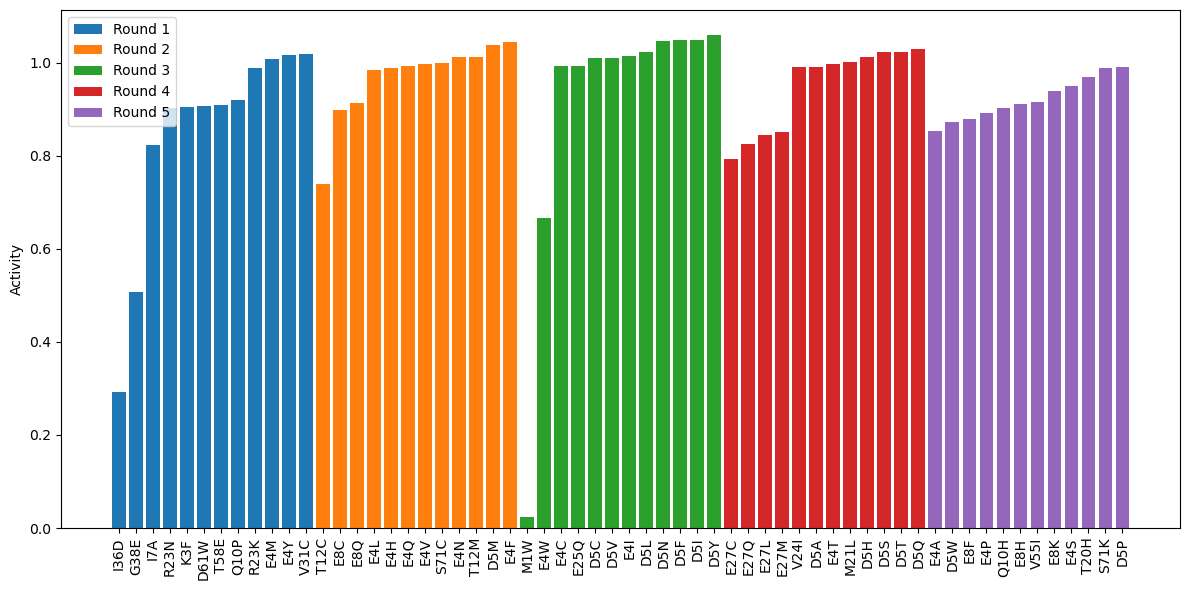

In [25]:
plot_variants_by_iteration(df, activity_column='activity', output_dir=colab_output, output_file="kelsic")

In [ ]:
plot